# Chemulator vs mini-chem Comparison

Addressing reviewer comment 3: *"For the results, do you want to compare with mini-chem? Even though we are doing the one-shot prediction."*

We compare three approaches on the same test trajectories:

| Method | Description | Mode |
|--------|-------------|------|
| **VULCAN** | Ground truth | Full NCHO kinetic network, time-stepped |
| **Chemulator** | Neural emulator (this work) | One-shot: t₀ → any t in a single forward pass |
| **mini-chem** | Reduced network surrogate | 10 net reactions (NCHO), sequential time-stepping |

**Strategy:** both Chemulator and mini-chem start from the same y[0] taken from the VULCAN trajectory.
Chemulator predicts all t[1:] simultaneously (one-shot, errors never compound).
mini-chem steps incrementally through the VULCAN time grid, using each step's output as the next step's input
(sequential, as it would be used inside a GCM).

**Sampling regime.** mini-chem's reduced 10-reaction NCHO network is calibrated and validated by Tsai et al. (2022) for
T ∈ [1000, 2500] K and P ∈ [10², 10⁷] Pa (≈1 mbar – 100 bar). Outside this regime the rate tables can still be
interpolated but the dominant pathways shift to reactions not in the reduced network, so any error attribution would
conflate "reduced vs full network" with "out-of-validation extrapolation." To keep the comparison fair we restrict
the test sample to that calibrated regime and report per-trajectory distributions, not single anecdotes.

In [1]:
import json
import subprocess
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.lines import Line2D

# Resolve repo root whether launched from testing/ or Chemulator/
_cwd = Path().resolve()
REPO          = _cwd if (_cwd / "models" / "final_model").exists() else _cwd.parent
TESTING_DIR   = REPO / "testing"
MODEL_DIR     = REPO / "models" / "final_model"
SHARD         = REPO / "data" / "processed" / "test" / "shard_test_mix_r2_200015.npz"
MINI_CHEM_DIR = REPO.parent / "mini_chem"
MINI_CHEM_SRC = MINI_CHEM_DIR / "src_mini_chem_dlsode"
MINI_CHEM_BIN = MINI_CHEM_DIR / "mini_chem_dlsode"
MINI_CHEM_NML = MINI_CHEM_DIR / "mini_chem.nml"
MINI_CHEM_OUT = MINI_CHEM_DIR / "outputs_dlsode" / "dlsode.txt"
PAPER_DIR     = REPO.parent / "Chemulator_ApJ"   # figures are written straight to the manuscript

try:
    plt.style.use(str(TESTING_DIR / "science.mplstyle"))
except OSError:
    warnings.warn("science.mplstyle not found; using matplotlib defaults.")

# Load exported Chemulator model
ep         = torch.export.load(MODEL_DIR / "physical_model_k1_cpu.pt2")
chem_model = ep.module()

meta    = json.loads((MODEL_DIR / "physical_model_metadata.json").read_text())
SPECIES = meta["species_order"]                        # ["C2H2_evolution", ...]
NAMES   = [s.removesuffix("_evolution") for s in SPECIES]
N_SP    = len(SPECIES)                                 # 12

d     = np.load(SHARD, allow_pickle=False)
y_mat = d["y_mat"].astype(np.float32)    # (N_traj, 100, 12)  mixing ratios
g_mat = d["globals"].astype(np.float32)  # (N_traj, 2)        [P_barye, T_K]
t_vec = d["t_vec"].astype(np.float32)    # (100,)             shared time grid [s]
N_TRAJ, N_TIME, _ = y_mat.shape
TINY  = 1e-35

# Stored pressure is dyn/cm^2 (VULCAN cgs), not Pa: the shard values span
# 1 -> 1e10, i.e. 1e-6 -> 1e4 bar.  mini-chem's namelist P_in is in Pa
# (mini_ch_i_dlsode.f90: P_cgs = P_in * 10.0_dp).  Convert once here and use
# P_Pa_all everywhere a pressure is passed to mini-chem, filtered on, or
# printed.  The emulator is fed g_mat unchanged: it was trained on the stored
# representation.
BARYE_TO_PA = 0.1
P_Pa_all = BARYE_TO_PA * g_mat[:, 0].astype(np.float64)


print(f"Loaded {N_TRAJ:,} test trajectories × {N_TIME} timesteps × {N_SP} species")
print(f"P range : {P_Pa_all.min():.1e} → {P_Pa_all.max():.1e} Pa")
print(f"T range : {g_mat[:,1].min():.0f} → {g_mat[:,1].max():.0f} K")
print(f"t range : {t_vec[0]:.2e} → {t_vec[-1]:.2e} s")

Loaded 32,624 test trajectories × 100 timesteps × 12 species
P range : 1.0e-01 → 1.0e+09 Pa
T range : 300 → 3000 K
t range : 0.00e+00 → 1.00e+08 s


## Species Mapping

mini-chem NCHO has 13 species (12 active + He as a passive tracer).  All 12 Chemulator species are present.

| Chemulator idx | Name  | mini-chem idx |
|:-:|:-:|:-:|
| 0  | C2H2 | 8  |
| 1  | CH4  | 7  |
| 2  | CO2  | 5  |
| 3  | CO   | 4  |
| 4  | H2O  | 2  |
| 5  | H2   | 1  |
| 6  | HCN  | 11 |
| 7  | H    | 3  |
| 8  | N2   | 10 |
| 9  | NH3  | 9  |
| 10 | OH   | 0  |
| 11 | O    | 6  |

He (mini-chem index 12) is set to 0. The Chemulator training data was post-processed to renormalize VMRs over the
12 active species (He removed); each trajectory's species sum to ≈1 at every timestep, so mini-chem's input-VMR
renormalization (`VMR_IC/sum(VMR_IC)`) is a near-no-op.

In [2]:
# mini-chem NCHO output order: OH H2 H2O H CO CO2 O CH4 C2H2 NH3 N2 HCN He
# CHEM_TO_MINI[i] = j  →  Chemulator species i lives at mini-chem column j
CHEM_TO_MINI = [8, 7, 5, 4, 2, 1, 11, 3, 10, 9, 0, 6]

def chem_to_mini_vmr(vmr_chem: np.ndarray) -> np.ndarray:
    """VMR from Chemulator order (12,) → mini-chem order (13,) with He=0."""
    vmr_mini = np.zeros(13)
    vmr_mini[CHEM_TO_MINI] = vmr_chem
    return vmr_mini

def mini_to_chem_vmr(vmr_mini: np.ndarray) -> np.ndarray:
    """VMR from mini-chem output (13 or 12 cols) → Chemulator order (12,)."""
    return np.array(vmr_mini[:12])[CHEM_TO_MINI]

## Build mini-chem

Compile the Fortran dlsode binary if not already built.  Requires `gfortran`.

In [3]:
def build_minichem() -> None:
    if MINI_CHEM_BIN.exists():
        print(f"Binary already present: {MINI_CHEM_BIN}")
        return
    print("Compiling mini-chem (dlsode) …")
    result = subprocess.run(
        ["make"],
        cwd=str(MINI_CHEM_SRC),
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        print("STDOUT:", result.stdout[-3000:])
        print("STDERR:", result.stderr[-3000:])
        raise RuntimeError("make failed — check gfortran installation.")
    assert MINI_CHEM_BIN.exists(), f"Expected binary at {MINI_CHEM_BIN}"
    print("Compiled successfully.")

build_minichem()

Binary already present: /Users/imalsky/Desktop/Emulators/Chemulator_Project/mini_chem/mini_chem_dlsode


## Helper Functions

In [4]:
def _write_nml(T_K: float, P_Pa: float, vmr_mini: np.ndarray, t_step: float) -> None:
    """Overwrite mini_chem.nml for a single-step run."""
    vmr_str = ", ".join(f"{max(float(v), 0.0):.10e}" for v in vmr_mini)
    nml = (
        "&mini_chem\n"
        f"network = 'NCHO'\n"
        f"T_in = {T_K:.6f}\n"
        f"P_in = {P_Pa:.10e}\n"
        f"t_step = {t_step:.10e}\n"
        "n_step = 1\n"
        "n_sp = 13\n"
        "data_file = 'chem_data/mini_chem_data_NCHO.txt'\n"
        "sp_file = 'chem_data/mini_chem_sp_NCHO.txt'\n"
        "net_dir = 'chem_data/1x/'\n"
        "met = '1x'\n"
        "/\n"
        "\n"
        "&mini_chem_VMR\n"
        "CE_IC = .False.\n"
        "IC_file = 'chem_data/IC/mini_chem_IC_FastChem_1x.txt'\n"
        f"VMR_IC = {vmr_str}\n"
        "/\n"
    )
    MINI_CHEM_NML.write_text(nml)


def _run_one_step(T_K: float, P_Pa: float, vmr_chem: np.ndarray, dt: float) -> np.ndarray:
    """Run mini-chem for one time step dt.  Returns updated VMR in Chemulator order (12,)."""
    vmr_mini = chem_to_mini_vmr(np.clip(vmr_chem, 0.0, None))
    _write_nml(T_K, P_Pa, vmr_mini, t_step=dt)
    result = subprocess.run(
        [str(MINI_CHEM_BIN)],
        cwd=str(MINI_CHEM_DIR),
        capture_output=True,
        text=True,
        timeout=60,
    )
    if result.returncode != 0:
        raise RuntimeError(
            f"mini_chem failed (dt={dt:.3e} s, T={T_K:.0f} K, P={P_Pa:.2e} Pa):\n"
            + result.stderr[-500:]
        )
    data = np.loadtxt(MINI_CHEM_OUT, skiprows=1, ndmin=2)   # (>=1, 15): [n, t, 12 sp, He] -- ndmin=2 keeps shape stable for n_step=1
    return mini_to_chem_vmr(data[-1, 2:])           # post-step row, 13 VMR cols


def run_minichem_trajectory(traj_idx: int) -> np.ndarray:
    """Step mini-chem through the full VULCAN time grid from y_mat[traj_idx, 0].

    Returns (N_TIME, N_SP) in Chemulator species order; row 0 is the IC.
    Performs N_TIME-1 subprocess calls (≈10–30 s on a laptop).
    """
    y0   = y_mat[traj_idx, 0].astype(np.float64)
    T_K  = float(g_mat[traj_idx, 1])
    P_Pa = float(P_Pa_all[traj_idx])

    results = [y0.copy()]
    vmr_now = y0.copy()
    for i in range(1, N_TIME):
        dt      = float(t_vec[i] - t_vec[i - 1])
        vmr_now = _run_one_step(T_K, P_Pa, vmr_now, dt).astype(np.float64)
        results.append(vmr_now.copy())
    return np.array(results, dtype=np.float32)

In [5]:
def predict_chemulator(traj_idx: int) -> np.ndarray:
    """One-shot Chemulator prediction for all t[1:] from y[0]. Returns (N_TIME-1, N_SP)."""
    y0   = y_mat[traj_idx, 0]
    g    = g_mat[traj_idx]
    dt   = (t_vec[1:] - t_vec[0]).astype(np.float32)
    N    = len(dt)
    y_b  = torch.from_numpy(y0[None]).float().repeat(N, 1)
    g_b  = torch.from_numpy(g[None]).float().repeat(N, 1)
    dt_b = torch.from_numpy(dt).float().view(-1, 1)
    with torch.no_grad():
        return chem_model(y_b, dt_b, g_b)[:, 0, :].numpy()

## Sanity Check

One single-step mini-chem call before the batch run, on trajectory 0.

In [6]:
_y0 = y_mat[0, 0]
_g  = g_mat[0]
_dt = float(t_vec[1] - t_vec[0])

_vmr_out = _run_one_step(float(_g[1]), float(P_Pa_all[0]), _y0, _dt)
print("mini-chem sanity check passed.")
print(f"  T={_g[1]:.0f} K  P={P_Pa_all[0]:.2e} Pa  dt={_dt:.3e} s")
for name, v_in, v_out in zip(NAMES, _y0, _vmr_out):
    if max(v_in, v_out) > 1e-15:
        print(f"  {name:5s}: {v_in:.3e} → {v_out:.3e}")

mini-chem sanity check passed.
  T=1146 K  P=6.97e+05 Pa  dt=1.000e-03 s
  C2H2 : 1.541e-04 → 1.567e-04
  CH4  : 1.165e-06 → 2.397e-06
  CO2  : 7.087e-03 → 6.673e-03
  CO   : 4.632e-07 → 5.585e-04
  H2O  : 1.748e-14 → 5.625e-04
  H2   : 9.527e-01 → 9.920e-01
  H    : 4.008e-02 → 6.642e-05
  N2   : 1.388e-12 → 1.416e-12
  NH3  : 2.057e-10 → 2.099e-10
  OH   : 1.019e-12 → 8.321e-10
  O    : 4.362e-06 → 4.762e-14


## Sample Selection (Tsai+2022 Validation Regime)

mini-chem's rate tables under `chem_data/1x/` are tabulated for T ∈ [300, 3451] K and P ∈ [10⁻³, 10⁸] Pa, but the
reduced 10-reaction NCHO network was *validated* against the full VULCAN network only for **T ∈ [1000, 2500] K and
P ∈ [10², 10⁷] Pa**. We restrict the comparison to that regime and stratify the sample across it so the summary
statistics aren't dominated by a single corner.

`N_STATS` trajectories drives the boxplot / quantitative comparison; three representative trajectories from the
same sample (low/mid/high in (logP, T)) are shown as line plots. The sample is large (1000) to give the
fractional-error distribution enough resolution to clearly separate the two methods.

In [7]:
RG_T = (1000.0, 2500.0)   # K   — Tsai+2022 validation range
RG_P = (1e2,    1e7)      # Pa  — Tsai+2022 validation range
N_STATS = 1000
SEED = 42

mask_regime = (
    (P_Pa_all >= RG_P[0]) & (P_Pa_all <= RG_P[1]) &
    (g_mat[:, 1] >= RG_T[0]) & (g_mat[:, 1] <= RG_T[1])
)
regime_idxs = np.where(mask_regime)[0]
print(f"Trajectories inside Tsai+2022 regime: {len(regime_idxs):,} / {N_TRAJ:,}")
assert len(regime_idxs) >= N_STATS, "Too few in-regime trajectories."

def stratified_sample(rng, idxs, k, nbins=5):
    """Pick k trajectories distributed across an nbins x nbins (logP, T) grid."""
    edges_p = np.linspace(np.log10(RG_P[0]), np.log10(RG_P[1]), nbins + 1)
    edges_t = np.linspace(RG_T[0],            RG_T[1],            nbins + 1)
    bins: dict = {}
    for i in idxs:
        bp = int(np.clip(np.digitize(np.log10(P_Pa_all[i]), edges_p) - 1, 0, nbins - 1))
        bt = int(np.clip(np.digitize(g_mat[i, 1],            edges_t) - 1, 0, nbins - 1))
        bins.setdefault((bp, bt), []).append(int(i))

    keys = list(bins.keys())
    rng.shuffle(keys)
    out: list[int] = []
    while keys and len(out) < k:
        next_keys = []
        for kk in keys:
            if not bins[kk]:
                continue
            j = int(rng.integers(0, len(bins[kk])))
            out.append(bins[kk].pop(j))
            if len(out) == k:
                break
            if bins[kk]:
                next_keys.append(kk)
        keys = next_keys
    return np.array(sorted(out), dtype=int)

rng = np.random.default_rng(SEED)
stat_idxs = stratified_sample(rng, regime_idxs, N_STATS)

P_sample = P_Pa_all[stat_idxs]
T_sample = g_mat[stat_idxs, 1]
print(f"\nStratified sample of {len(stat_idxs)} trajectories:")
print(f"  P range  : {P_sample.min():.2e} → {P_sample.max():.2e} Pa")
print(f"  T range  : {T_sample.min():.0f} → {T_sample.max():.0f} K")
print(f"  log10P   median = {np.median(np.log10(P_sample)):.2f}")
print(f"  T        median = {np.median(T_sample):.0f} K")

Trajectories inside Tsai+2022 regime: 10,849 / 32,624



Stratified sample of 1000 trajectories:
  P range  : 1.02e+02 → 9.99e+06 Pa
  T range  : 1001 → 2500 K
  log10P   median = 4.56
  T        median = 1742 K


## Run mini-chem and Chemulator on the Sample

≈ 3–5 s per trajectory (99 mini-chem subprocess calls each), so ~50–80 minutes for `N_STATS=1000`.
Results are written to a compressed NPZ cache keyed by `(N_STATS, SEED)` so subsequent runs of this
notebook skip the expensive mini-chem stepping entirely. Set `FORCE_RERUN=True` (or delete the cache
file) to regenerate.

In [8]:
import time

CACHE_DIR  = TESTING_DIR / "cache"
CACHE_DIR.mkdir(exist_ok=True)
CACHE_PATH = CACHE_DIR / f"minichem_compare_n{N_STATS}_s{SEED}.npz"
FORCE_RERUN = False

results_store: dict[int, tuple[np.ndarray, np.ndarray, np.ndarray]] = {}

if CACHE_PATH.exists() and not FORCE_RERUN:
    z = np.load(CACHE_PATH)
    cached_idxs = z["stat_idxs"]
    if not np.array_equal(cached_idxs, stat_idxs):
        raise RuntimeError(
            f"Cached stat_idxs differ from current selection — "
            f"delete {CACHE_PATH.name} or set FORCE_RERUN=True."
        )
    y_truth_all, y_chem_all, y_mc_all = z["y_truth"], z["y_chem"], z["y_mc"]
    for i, ti in enumerate(cached_idxs):
        results_store[int(ti)] = (y_truth_all[i], y_chem_all[i], y_mc_all[i])
    print(f"Loaded cache: {CACHE_PATH.name}  ({len(results_store)} trajectories)")
else:
    t0 = time.time()
    PRINT_EVERY = max(1, len(stat_idxs) // 20)
    for k, ti in enumerate(stat_idxs, 1):
        ti = int(ti)
        y_chem = predict_chemulator(ti)
        y_mc   = run_minichem_trajectory(ti)
        results_store[ti] = (y_mat[ti].copy(), y_chem, y_mc)
        if k % PRINT_EVERY == 0 or k == len(stat_idxs):
            elapsed = time.time() - t0
            eta = elapsed / k * (len(stat_idxs) - k)
            print(f"[{k:4d}/{len(stat_idxs)}]  elapsed {elapsed:6.0f}s   ETA {eta:6.0f}s",
                  flush=True)
    print(f"\nDone in {time.time() - t0:.1f} s.")

    y_truth_all = np.stack([results_store[int(ti)][0] for ti in stat_idxs])
    y_chem_all  = np.stack([results_store[int(ti)][1] for ti in stat_idxs])
    y_mc_all    = np.stack([results_store[int(ti)][2] for ti in stat_idxs])
    np.savez_compressed(
        CACHE_PATH,
        stat_idxs=stat_idxs,
        y_truth=y_truth_all,
        y_chem=y_chem_all,
        y_mc=y_mc_all,
    )
    print(f"Saved cache: {CACHE_PATH}  ({CACHE_PATH.stat().st_size / 1e6:.1f} MB)")

Loaded cache: minichem_compare_n1000_s42.npz  (1000 trajectories)


## Comparison Plots

Three representative trajectories from the regime sample (low / mid / high on a combined log-P + normalized-T axis).
Solid = VULCAN truth, dashed = Chemulator one-shot, markers = mini-chem time-stepped.

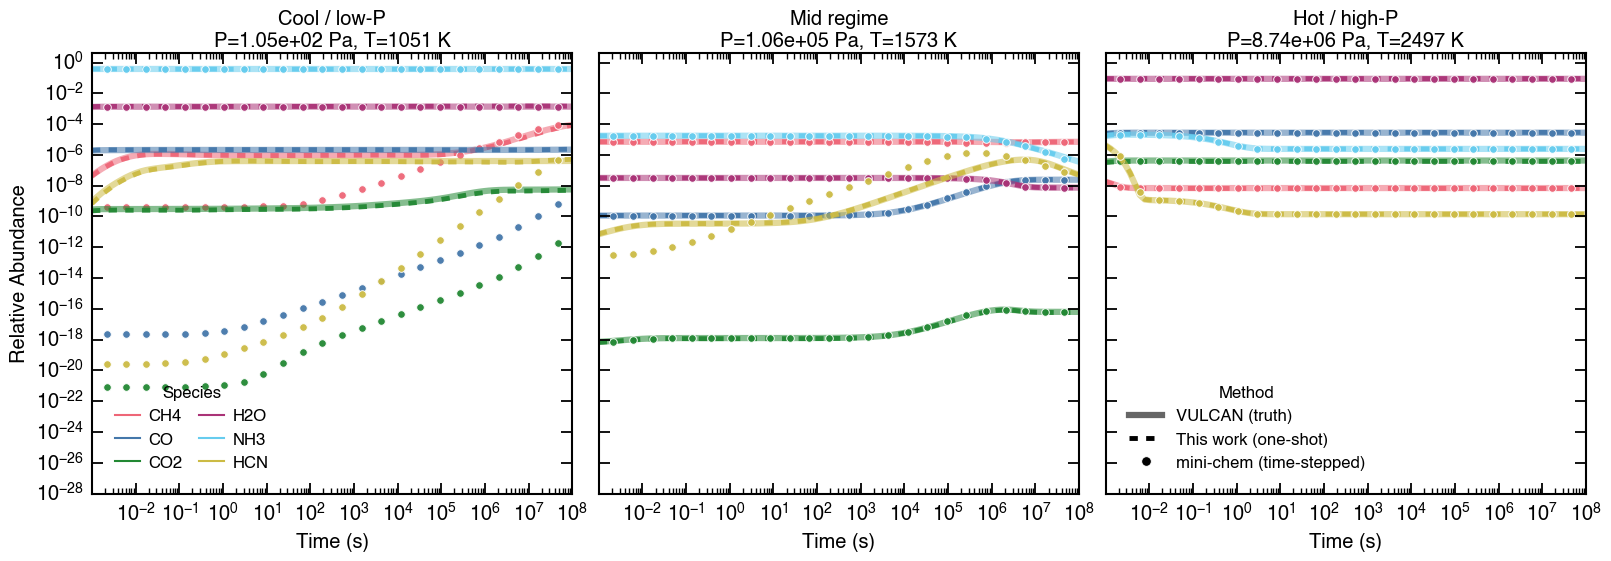

In [9]:
from matplotlib.lines import Line2D

PLOT_SPECIES = ["CH4", "CO", "CO2", "H2O", "NH3", "HCN"]

# Paul Tol bright palette — colorblind-safe
PLOT_COLORS = {
    "CH4": "#EE6677", "CO":  "#4477AA", "CO2": "#228833",
    "H2O": "#AA3377", "NH3": "#66CCEE", "HCN": "#CCBB44",
}
MC_MARKER_EVERY = 4
SPECIES_LEGEND_LW = 1.5


def plot_one(ax, traj_idx, label):
    y_true, y_chem, y_mc = results_store[int(traj_idx)]
    g  = g_mat[int(traj_idx)]
    sp_indices = [NAMES.index(sp) for sp in PLOT_SPECIES]
    step = max(1, MC_MARKER_EVERY)

    for sp_i, name in zip(sp_indices, PLOT_SPECIES):
        col = PLOT_COLORS[name]

        ax.loglog(
            t_vec,
            np.clip(y_true[:, sp_i], TINY, None),
            "-",
            color=col,
            lw=4.5,
            alpha=0.55,
        )

        ax.loglog(
            t_vec[1:],
            np.clip(y_chem[:, sp_i], TINY, None),
            "--",
            color=col,
            lw=3.5,
            alpha=0.95,
        )

        ax.loglog(
            t_vec[::step],
            np.clip(y_mc[::step, sp_i], TINY, None),
            marker="o",
            linestyle="None",
            color=col,
            markersize=5.5,
            markeredgecolor="white",
            markeredgewidth=0.7,
            alpha=0.95,
        )

    ax.set_xlabel("Time (s)")
    ax.set_title(f"{label}\nP={P_Pa_all[int(traj_idx)]:.2e} Pa, T={g[1]:.0f} K")
    ax.set_ylim(1e-28, 4)


# Pick three: lowest, median, highest along combined (logP + T-normalized) axis
def _score(i):
    return np.log10(P_Pa_all[i]) + (g_mat[i, 1] - RG_T[0]) / (RG_T[1] - RG_T[0]) * 4.0


sorted_idx = sorted(stat_idxs, key=_score)
plot_idxs = [sorted_idx[0], sorted_idx[len(sorted_idx) // 2], sorted_idx[-1]]
plot_labels = ["Cool / low-P", "Mid regime", "Hot / high-P"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5.5),
    sharey=True,
    constrained_layout=True,
)

for ax, ti, lbl in zip(axes, plot_idxs, plot_labels):
    plot_one(ax, ti, lbl)

axes[0].set_ylabel("Relative Abundance")

species_handles = [
    Line2D([0], [0], color=PLOT_COLORS[sp], lw=SPECIES_LEGEND_LW, label=sp)
    for sp in PLOT_SPECIES
]

method_handles = [
    Line2D([0], [0], color="k", lw=4.5, alpha=0.6, label="VULCAN (truth)"),
    Line2D([0], [0], color="k", lw=3.5, ls="--", label="This work (one-shot)"),
    Line2D(
        [0], [0],
        color="k",
        marker="o",
        linestyle="None",
        markersize=7,
        markeredgecolor="white",
        markeredgewidth=0.7,
        label="mini-chem (time-stepped)",
    ),
]

axes[0].legend(
    handles=species_handles,
    title="Species",
    ncol=2,
    loc="lower left",
    handlelength=1.5,
    handletextpad=0.5,
    columnspacing=1.0,
)

axes[-1].legend(
    handles=method_handles,
    title="Method",
    loc="lower left",
)

plt.show()


## Quantitative Error

We report the **mean absolute log10 error** (in dex) over all 12 species and 99 timesteps for each trajectory.
Concretely:

\\[
\\mathrm{err}_{\\rm traj} = \\overline{\\,\\bigl|\\,\\log_{10}\\!\\max(y_{\\rm pred}, \\varepsilon)\\;-\\;\\log_{10}\\!\\max(y_{\\rm true}, \\varepsilon)\\bigr|\\,}\\quad
\\varepsilon=10^{-30}.
\\]

The ε floor matches the preprocessing epsilon used during training and sits well below any physical mole
fraction in the dataset, so it only kicks in when a species is driven to numerical zero. Dex is the natural
metric for stiff chemistry: $0.30\\,\\mathrm{dex}$ ≈ a factor-of-2 multiplicative error, $1.0\\,\\mathrm{dex}$ =
order-of-magnitude error. We previously reported $|\\Delta|/y_{\\rm true}$ but that metric is dominated by a
~1% tail of trajectories where VULCAN drives a species below $10^{-20}$ — a denominator pathology rather than
a chemistry result.


In [10]:
EPS_DEX = 1e-30   # floor matches training-time normalization epsilon

def dex_err(y_pred, y_true, eps=EPS_DEX):
    """Mean |log10(y_pred) - log10(y_true)| in dex, with an eps floor on both arguments.

    Floor is well below any physical mole fraction in the dataset, so it only kicks in when
    a species is driven to numerical zero. Reported in dex (decimal exponents):
    0.30 dex ~ factor of 2 multiplicative error; 1.0 dex = order-of-magnitude error.
    """
    return float(np.mean(np.abs(
        np.log10(np.maximum(y_pred, eps))
        - np.log10(np.maximum(y_true, eps))
    )))


def abs_err(y_pred, y_true):
    """Complementary sanity metric: mean absolute mole-fraction error."""
    return float(np.mean(np.abs(y_pred - y_true)))


chem_dex, mc_dex = [], []
chem_abs, mc_abs = [], []
for ti in stat_idxs:
    yt, yc, ym = results_store[int(ti)]
    chem_dex.append(dex_err(yc,     yt[1:]))
    mc_dex.append(  dex_err(ym[1:], yt[1:]))
    chem_abs.append(abs_err(yc,     yt[1:]))
    mc_abs.append(  abs_err(ym[1:], yt[1:]))


def _stats(v):
    arr = np.asarray([x for x in v if not np.isnan(x)])
    return float(np.median(arr)), float(np.percentile(arr, 90)), float(arr.max())


print(f"Aggregate over {len(stat_idxs)} trajectories  (Tsai+2022 regime)")
print(f"  T in [{RG_T[0]:.0f}, {RG_T[1]:.0f}] K   "
      f"P in [{RG_P[0]:.0e}, {RG_P[1]:.0e}] Pa")
print(f"  Headline metric: mean |log10 y_pred - log10 y_true|, eps={EPS_DEX:.0e}")
print()
print(f"{'':32s}  {'This work (med / p90 / max)':>30s}    {'mini-chem (med / p90 / max)':>30s}")
print("-" * 100)
m = _stats(chem_dex); n = _stats(mc_dex)
print(f"{'log10 error (dex)':32s}  "
      f"{m[0]:>9.3f} / {m[1]:>6.3f} / {m[2]:>6.3f}    "
      f"{n[0]:>9.3f} / {n[1]:>6.3f} / {n[2]:>6.3f}")
m = _stats(chem_abs); n = _stats(mc_abs)
print(f"{'abs mole-frac error |y_p - y_t|':32s}  "
      f"{m[0]:>9.3e} / {m[1]:>6.3e} / {m[2]:>6.3e}    "
      f"{n[0]:>9.3e} / {n[1]:>6.3e} / {n[2]:>6.3e}")


Aggregate over 1000 trajectories  (Tsai+2022 regime)
  T in [1000, 2500] K   P in [1e+02, 1e+07] Pa
  Headline metric: mean |log10 y_pred - log10 y_true|, eps=1e-30

                                     This work (med / p90 / max)       mini-chem (med / p90 / max)
----------------------------------------------------------------------------------------------------
log10 error (dex)                     0.014 /  0.022 /  0.060        0.245 /  0.875 /  4.231
abs mole-frac error |y_p - y_t|   9.867e-05 / 8.375e-04 / 4.072e-03    8.314e-06 / 2.883e-03 / 4.277e-02


Distribution of trajectory-mean |log10 y_pred - log10 y_true| (dex):
  This Work   min=0.0039  median=0.0139  p90=0.0216  max=0.0600  n=1000
  mini-chem   min=0.0017  median=0.2454  p90=0.8749  max=4.2313  n=1000


saved /Users/imalsky/Desktop/Emulators/Chemulator_Project/Chemulator_ApJ/error.png


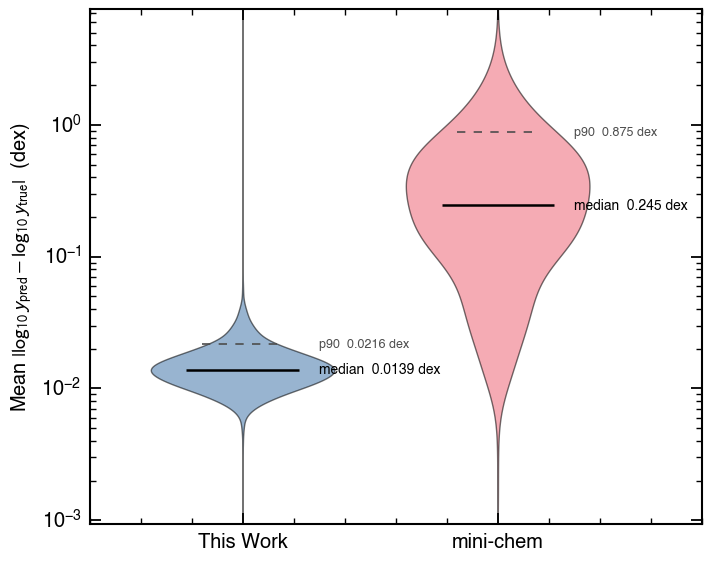

In [11]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(7, 5.5), constrained_layout=True)

labels    = ["This Work", "mini-chem"]
positions = [1, 2]
colors    = ["#4477AA", "#EE6677"]

# Drop NaNs and any non-positive values (log axis can\'t render those)
data = [
    np.asarray([v for v in chem_dex if not np.isnan(v) and v > 0]),
    np.asarray([v for v in mc_dex   if not np.isnan(v) and v > 0]),
]

print("Distribution of trajectory-mean |log10 y_pred - log10 y_true| (dex):")
for label, d in zip(labels, data):
    print(f"  {label:10s}  min={d.min():.4f}  median={np.median(d):.4f}  "
          f"p90={np.percentile(d, 90):.4f}  max={d.max():.4f}  n={len(d)}")

# Compute KDE in log10(dex) space so the violin shape is meaningful on a log axis.
# Render polygons via fill_betweenx; positions and widths are in x (categorical) units.
all_logs   = np.concatenate([np.log10(d) for d in data])
y_lo, y_hi = 10 ** (all_logs.min() - 0.25), 10 ** (all_logs.max() + 0.25)
y_grid     = np.logspace(np.log10(y_lo), np.log10(y_hi), 400)
log_grid   = np.log10(y_grid)
HALF_W     = 0.36   # half-width of each violin

for pos, d, c in zip(positions, data, colors):
    kde     = gaussian_kde(np.log10(d), bw_method=0.35)
    density = kde(log_grid)
    density = density / density.max() * HALF_W
    ax.fill_betweenx(y_grid, pos - density, pos + density,
                     facecolor=c, edgecolor="k", alpha=0.55, lw=1.0)

# Median + p90 marks
for pos, d in zip(positions, data):
    med = float(np.median(d))
    p90 = float(np.percentile(d, 90))
    ax.hlines(med, pos - 0.22, pos + 0.22, colors="k",   lw=1.8, zorder=5)
    ax.hlines(p90, pos - 0.16, pos + 0.16, colors="0.3", lw=1.2, ls="--", zorder=5)
    ax.text(pos + 0.30, med, f"median  {med:.3g} dex",
            va="center", ha="left", fontsize=10)
    ax.text(pos + 0.30, p90, f"p90  {p90:.3g} dex",
            va="center", ha="left", fontsize=9, color="0.3")

ax.set_yscale("log")
ax.set_ylim(y_lo, y_hi)
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_xlim(0.4, 2.8)
ax.set_ylabel(r"Mean $|\log_{10} y_{\mathrm{pred}} - \log_{10} y_{\mathrm{true}}|$  (dex)")

fig.savefig(PAPER_DIR / "error.png", dpi=200, bbox_inches="tight")
print(f"saved {PAPER_DIR / 'error.png'}")
plt.show()


## Discussion and Caveats

### Comparison setup

| | Chemulator | mini-chem |
|---|---|---|
| Network basis | Learned from VULCAN NCHO data | Analytical NCHO, 10 net reactions |
| Prediction mode | One-shot: y₀ → yₙ in one call | Sequential: yᵢ → yᵢ₊₁ at each step |
| Error accumulation | None (all preds from y₀) | Yes (steps compound, GCM-style use) |
| Requires training | Yes | No |
| Target use case | VULCAN-accuracy surrogate | Fast GCM coupling |

### Caveats

1. **Asymmetric prediction modes — by design.** Chemulator predicts every tₙ from the same y₀, so its errors
   never compound. mini-chem steps sequentially, which is exactly how it would be used inside a 3D GCM. This
   reflects how each tool would be deployed; it is not a head-to-head comparison of the underlying chemistry
   methods at fixed step count.

2. **Sample restricted to the validation regime.** All `N_STATS=1000` trajectories lie in T ∈ [1000, 2500] K
   and P ∈ [10², 10⁷] Pa, where Tsai+2022 demonstrated that the reduced 10-reaction network reproduces full
   VULCAN to within published tolerances. Outside this regime, dominant pathways shift to reactions not in
   the reduced network and any error attribution would conflate "reduced vs full network" with
   "out-of-validation extrapolation."

3. **Error metric is mean absolute log10 error in dex** with an ε=10⁻³⁰ floor on both `y_pred` and `y_true`,
   averaged over 12 species and 99 timesteps to give one scalar per trajectory. We picked dex over the
   raw fractional error `|Δ|/y_true` because the latter is dominated by a ~1% tail of trajectories in which
   VULCAN drives a species below 10⁻²⁰; the reduced 10-reaction NCHO network cannot reach those levels
   (lacks the corresponding destruction pathways), so the denominator vanishes and produces fractional
   errors of 10¹⁵ even though the absolute species disagreement is at most ~10⁻³ in mole fraction. Under dex
   the contrast is consistent and physically interpretable: 0.30 dex ≈ factor-of-2 error, 1.0 dex = order
   of magnitude. The sanity-check absolute mole-fraction error is reported alongside.

4. **He treatment.** The Chemulator training data sums to ≈1 over the 12 active species (He removed and
   renormalized at the data-generation stage). mini-chem's `VMR_IC/sum(VMR_IC)` step is therefore a
   near-no-op in our setup, so we are not silently rescaling ICs by ~10%. We verified this directly against
   the raw HDF5.

5. **Solar metallicity (1×).** VULCAN was run with `use_solar=True`, which matches mini-chem's `chem_data/1x/`
   rate-table set. mini-chem's `met='1x'` selection is consistent with the data.

6. **Result caching.** The expensive mini-chem run is cached to `testing/cache/minichem_compare_n{N}_s{SEED}.npz`
   and reloaded on subsequent runs. Delete the file or set `FORCE_RERUN=True` to regenerate; the cache stores
   raw species-level VMRs so the metric can be re-derived without re-stepping mini-chem.
